# Text Preprocessing: 20 Newsgroups

This notebook applies text preprocessing to the 20 Newsgroups dataset — lowercasing, punctuation removal, stopword removal, and lemmatization — then saves the cleaned text to S3 for use in topic modeling.

**Input**: `s3://topic-modeling-demo/00_data_collection/newsgroups.parquet`  
**Output**: `s3://topic-modeling-demo/02_preprocessing/newsgroups_preprocessed.parquet`

## Imports

In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from io import BytesIO
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# download NLTK data
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)

print('All imports successful')

All imports successful


## Helper Class

In [2]:
class TextPreprocessor:
    """Text preprocessing for topic modeling."""
    
    def __init__(self, str_bucket, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_dirname_output = str_dirname_output
        self.s3_client = boto3.client('s3', region_name='us-east-1')
        self.df_data = None
        self.lemmatizer = WordNetLemmatizer()
        self.set_stopwords = set(stopwords.words('english'))
        # add domain-specific stopwords
        self.set_stopwords.update([
            'would', 'could', 'also', 'one', 'two', 'get', 'got', 'like',
            'know', 'think', 'make', 'even', 'well', 'much', 'say', 'said',
            'people', 'way', 'use', 'used', 'many', 'may', 'new', 'really',
            'go', 'see', 'come', 'take', 'good', 'first', 'back', 'want',
            'time', 'right', 'still', 'need', 'thing', 'something', 'tell',
            'look', 'give', 'seem', 'find', 'let', 'try', 'put', 'call',
            'keep', 'work', 'long', 'made', 'going', 'point', 'since',
            'however', 'though', 'actually', 'already', 'without', 'rather',
            'quite', 'anything', 'everything', 'nothing', 'enough'
        ])
        self.set_plot_style()
    
    def set_plot_style(self):
        """Configure matplotlib/seaborn styling."""
        sns.set_style('whitegrid')
        plt.rcParams['figure.figsize'] = (14, 6)
        plt.rcParams['font.size'] = 11
    
    def import_data(self):
        """Load cleaned data from S3."""
        str_uri = f's3://{self.str_bucket}/00_data_collection/newsgroups.parquet'
        self.df_data = pd.read_parquet(str_uri)
        print(f'Loaded {len(self.df_data):,} posts from S3')
    
    def clean_text(self, str_text):
        """Clean and preprocess a single text document."""
        # lowercase
        str_text = str_text.lower()
        # remove email addresses
        str_text = re.sub(r'\S+@\S+', '', str_text)
        # remove URLs
        str_text = re.sub(r'http\S+|www\S+', '', str_text)
        # remove numbers
        str_text = re.sub(r'\d+', '', str_text)
        # remove punctuation and special characters
        str_text = re.sub(r'[^a-z\s]', '', str_text)
        # remove extra whitespace
        str_text = re.sub(r'\s+', ' ', str_text).strip()
        # tokenize
        lst_tokens = word_tokenize(str_text)
        # remove stopwords and short words, then lemmatize
        lst_tokens = [
            self.lemmatizer.lemmatize(str_word)
            for str_word in lst_tokens
            if str_word not in self.set_stopwords and len(str_word) > 2
        ]
        return ' '.join(lst_tokens)
    
    def preprocess_all_data(self):
        """Apply text cleaning to entire dataset."""
        print('\nPreprocessing all posts...')
        lst_cleaned = []
        for str_text in tqdm(self.df_data['text'], desc='Cleaning text'):
            str_cleaned = self.clean_text(str_text)
            lst_cleaned.append(str_cleaned)
        self.df_data['text_clean'] = lst_cleaned
        
        # add cleaned word count
        self.df_data['clean_word_count'] = self.df_data['text_clean'].str.split().str.len()
        
        # remove posts that became empty after cleaning
        int_before = len(self.df_data)
        self.df_data = self.df_data[self.df_data['clean_word_count'] > 3].copy()
        self.df_data = self.df_data.reset_index(drop=True)
        int_removed = int_before - len(self.df_data)
        print(f'\nPreprocessed {len(self.df_data):,} posts')
        print(f'Removed {int_removed:,} posts with fewer than 4 words after cleaning')
    
    def plot_before_after_length(self):
        """Compare word counts before and after preprocessing."""
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        axes[0].hist(self.df_data['word_count'], bins=50, color='steelblue',
                     edgecolor='black', alpha=0.7)
        axes[0].set_xlabel('Word Count', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Number of Posts', fontsize=12, fontweight='bold')
        axes[0].set_title('Before Preprocessing', fontsize=13, fontweight='bold')
        axes[0].axvline(self.df_data['word_count'].median(), color='red',
                        linestyle='--', linewidth=2,
                        label=f'Median: {self.df_data["word_count"].median():,.0f}')
        axes[0].legend(fontsize=11)
        axes[0].set_xlim(0, self.df_data['word_count'].quantile(0.95))
        
        axes[1].hist(self.df_data['clean_word_count'], bins=50, color='#DD8452',
                     edgecolor='black', alpha=0.7)
        axes[1].set_xlabel('Word Count', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Number of Posts', fontsize=12, fontweight='bold')
        axes[1].set_title('After Preprocessing', fontsize=13, fontweight='bold')
        axes[1].axvline(self.df_data['clean_word_count'].median(), color='red',
                        linestyle='--', linewidth=2,
                        label=f'Median: {self.df_data["clean_word_count"].median():,.0f}')
        axes[1].legend(fontsize=11)
        axes[1].set_xlim(0, self.df_data['clean_word_count'].quantile(0.95))
        
        plt.suptitle('Word Count Distribution: Before vs. After Preprocessing',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/01_before_after_length.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 01_before_after_length.png')
    
    def plot_cleaned_word_frequency(self):
        """Plot top words after preprocessing."""
        lst_all_words = []
        for str_text in self.df_data['text_clean']:
            lst_all_words.extend(str_text.split())
        
        dict_word_counts = Counter(lst_all_words)
        lst_top_30 = dict_word_counts.most_common(30)
        
        fig, ax = plt.subplots(figsize=(14, 8))
        lst_words = [str_w for str_w, _ in lst_top_30]
        lst_counts = [int_c for _, int_c in lst_top_30]
        
        ax.barh(range(len(lst_words)), lst_counts, color='#DD8452', edgecolor='black')
        ax.set_yticks(range(len(lst_words)))
        ax.set_yticklabels(lst_words)
        ax.invert_yaxis()
        ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
        ax.set_title('Top 30 Words After Preprocessing', fontsize=14, fontweight='bold')
        
        for int_i, int_v in enumerate(lst_counts):
            ax.text(int_v + max(lst_counts)*0.01, int_i, f'{int_v:,}',
                    ha='left', va='center', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/02_cleaned_word_frequency.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 02_cleaned_word_frequency.png')
    
    def upload_to_s3(self):
        """Upload preprocessed data to S3."""
        str_s3_output_path = '02_preprocessing/newsgroups_preprocessed.parquet'
        
        buffer = BytesIO()
        self.df_data.to_parquet(buffer, index=False, engine='pyarrow')
        buffer.seek(0)
        
        self.s3_client.put_object(
            Bucket=self.str_bucket,
            Key=str_s3_output_path,
            Body=buffer.getvalue(),
            ContentType='application/octet-stream'
        )
        
        str_s3_uri = f's3://{self.str_bucket}/{str_s3_output_path}'
        print(f'Successfully uploaded preprocessed data to S3')
        print(f'  S3 URI: {str_s3_uri}')
    
    def print_summary(self):
        """Print preprocessing summary."""
        print('\n' + '='*60)
        print('PREPROCESSING SUMMARY')
        print('='*60)
        print(f'\nTotal posts after preprocessing: {len(self.df_data):,}')
        print(f'\nOriginal word count (mean): {self.df_data["word_count"].mean():,.0f}')
        print(f'Cleaned word count (mean): {self.df_data["clean_word_count"].mean():,.0f}')
        flt_reduction = (1 - self.df_data['clean_word_count'].mean() / self.df_data['word_count'].mean()) * 100
        print(f'Average reduction: {flt_reduction:.1f}%')
        print(f'\nPreprocessing steps applied:')
        print(f'  1. Lowercasing')
        print(f'  2. Email/URL removal')
        print(f'  3. Number removal')
        print(f'  4. Punctuation removal')
        print(f'  5. Stopword removal')
        print(f'  6. Lemmatization')
        print(f'  7. Short word removal (<=2 characters)')
        print('='*60)
        
        print('\nSample cleaned text:')
        for int_i in range(3):
            print(f'\n--- Post {int_i + 1} ---')
            print(f'Original: {self.df_data["text"].iloc[int_i][:200]}...')
            print(f'Cleaned:  {self.df_data["text_clean"].iloc[int_i][:200]}...')

## Constants

In [3]:
# S3 configuration
str_bucket = 'topic-modeling-demo'

# output directory
str_dirname_output = './output'

print(f'S3 Bucket: {str_bucket}')
print(f'Output Directory: {str_dirname_output}')

S3 Bucket: topic-modeling-demo
Output Directory: ./output


## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
    print(f'Created output directory: {str_dirname_output}')
except FileExistsError:
    print(f'Output directory already exists: {str_dirname_output}')

Created output directory: ./output


## Run Preprocessing

In [5]:
cls_preprocessor = TextPreprocessor(str_bucket=str_bucket, str_dirname_output=str_dirname_output)
cls_preprocessor.import_data()

Loaded 18,178 posts from S3


In [6]:
cls_preprocessor.preprocess_all_data()


Preprocessing all posts...


Cleaning text: 100%|██████████| 18178/18178 [00:21<00:00, 829.54it/s] 



Preprocessed 17,841 posts
Removed 337 posts with fewer than 4 words after cleaning


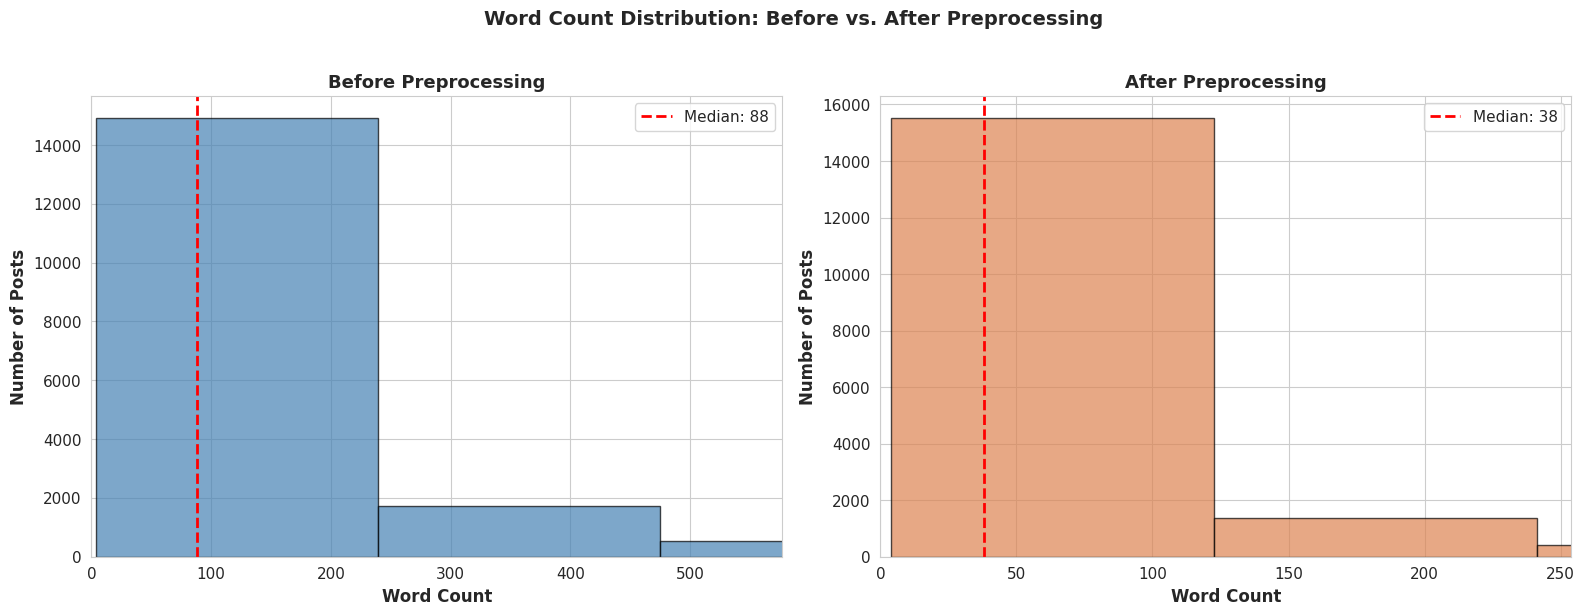

Saved: 01_before_after_length.png


In [7]:
cls_preprocessor.plot_before_after_length()

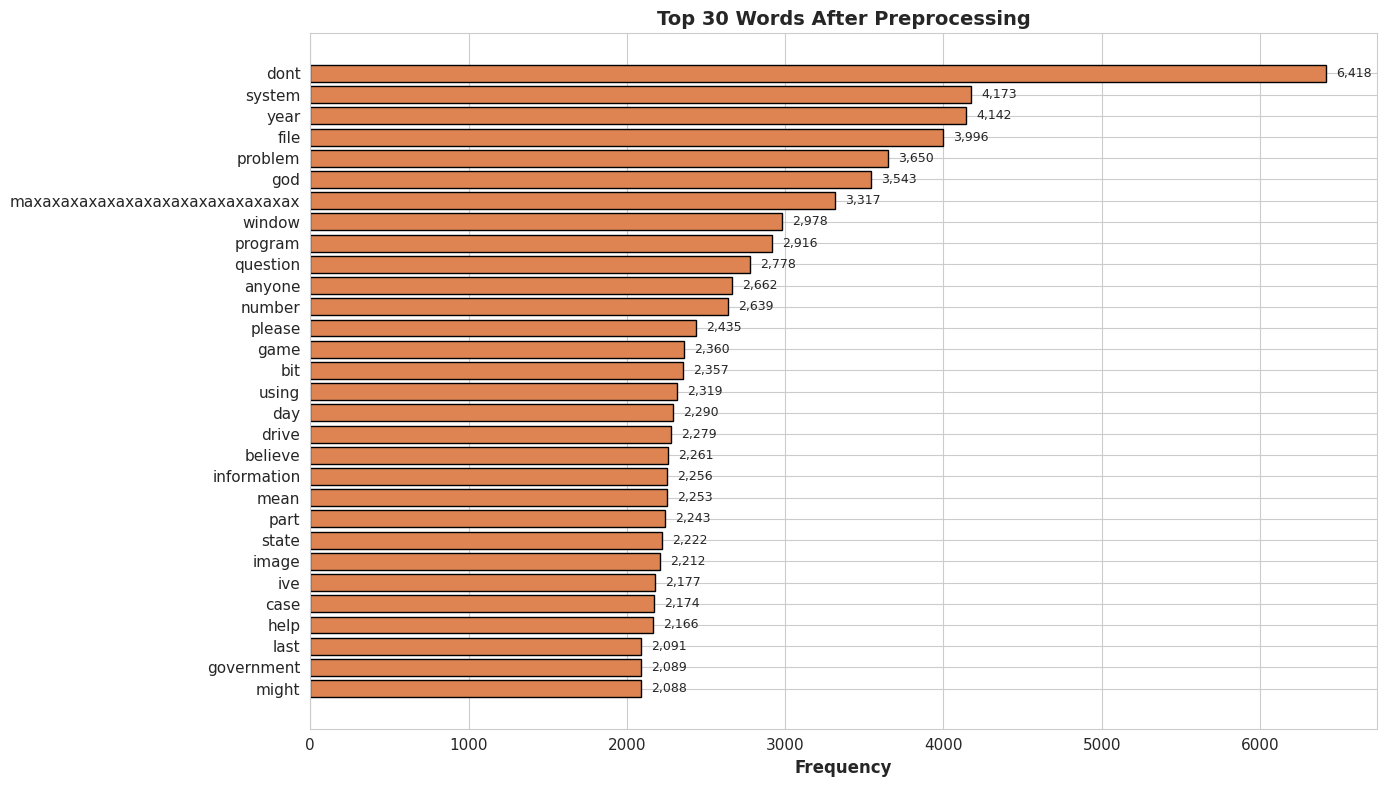

Saved: 02_cleaned_word_frequency.png


In [8]:
cls_preprocessor.plot_cleaned_word_frequency()

In [9]:
cls_preprocessor.upload_to_s3()

Successfully uploaded preprocessed data to S3
  S3 URI: s3://topic-modeling-demo/02_preprocessing/newsgroups_preprocessed.parquet


In [10]:
cls_preprocessor.print_summary()


PREPROCESSING SUMMARY

Total posts after preprocessing: 17,841

Original word count (mean): 191
Cleaned word count (mean): 85
Average reduction: 55.6%

Preprocessing steps applied:
  1. Lowercasing
  2. Email/URL removal
  3. Number removal
  4. Punctuation removal
  5. Stopword removal
  6. Lemmatization
  7. Short word removal (<=2 characters)

Sample cleaned text:

--- Post 1 ---
Original: 

I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However,...
Cleaned:  sure bashers pen fan pretty confused lack kind post recent pen massacre devil bit puzzled bit relieved end nonpittsburghers relief bit praise pen man killing devil worse thought jagr showed better reg...

--- Post 2 ---
Original: My brother is in the market for a high-performance video card that supports
VESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:

  - Diamond